# Notebook de Evidencias: Auditoria Proxy-Safe y Reentrenamiento Multiclase

Este notebook consolida y ejecuta todas las iteraciones y pruebas del informe, y deja evidencia reproducible de: deteccion de proxies, remocion, reentrenamiento y comparaciones finales.

## 1. Configuracion del Entorno y Reproducibilidad

In [1]:
import json
import hashlib
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COLUMN = 'ciclo_de_cultivo'
np.random.seed(RANDOM_STATE)

ROOT = Path('.')
DATA_PATH = ROOT / 'data' / 'Evaluaciones_Agropecuarias_Municipales_EVA.csv'
REPORT_DIR = ROOT / 'reports' / 'informe_modelado_proxy_safe'
OUT_DIR = ROOT / 'reports' / 'notebook_evidencias_proxy_safe'
ASSETS_DIR = OUT_DIR / 'assets'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Python:', platform.python_version())
print('OS:', platform.platform())
print('Random state:', RANDOM_STATE)
print('Data path exists:', DATA_PATH.exists())
print('Output dir:', OUT_DIR)

Python: 3.13.13
OS: Windows-11-10.0.26200-SP0
Random state: 42
Data path exists: True
Output dir: reports\notebook_evidencias_proxy_safe


## 2. Carga del Dataset Original y Versionado de Evidencias

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No existe el dataset en: {DATA_PATH}')

raw_bytes = DATA_PATH.read_bytes()
file_hash = hashlib.sha256(raw_bytes).hexdigest()
df_raw = pd.read_csv(DATA_PATH)

dataset_meta = {
    'file': str(DATA_PATH),
    'sha256': file_hash,
    'rows': int(df_raw.shape[0]),
    'cols': int(df_raw.shape[1]),
    'columns': list(df_raw.columns)
}

with open(OUT_DIR / 'dataset_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(dataset_meta, f, ensure_ascii=False, indent=2)

print('Hash SHA256:', file_hash[:20] + '...')
print('Shape:', df_raw.shape)
display(df_raw.head(3))

Hash SHA256: 2aa6726284b55a39651c...
Shape: (206068, 17)


,CÓD. \r\nDEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO \r\nDE CULTIVO,SUBGRUPO \r\nDE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada\r\n(ha),Área Cosechada\r\n(ha),Producción\r\n(t),Rendimiento\r\n(t/ha),ESTADO FISICO PRODUCCION,NOMBRE \r\nCIENTIFICO,CICLO DE CULTIVO
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,"1,440",18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


## 3. Perfilado Inicial y Diagnostico de Variables

In [3]:
import re
import unicodedata

def normalize_header(text):
    s = str(text).replace('\n', ' ').strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def standardize_eva_columns(df_input):
    target_map = {
        'cod dep': 'c_d_dep',
        'departamento': 'departamento',
        'cod mun': 'c_d_mun',
        'municipio': 'municipio',
        'grupo de cultivo': 'grupo_de_cultivo',
        'subgrupo de cultivo': 'subgrupo_de_cultivo',
        'cultivo': 'cultivo',
        'desagregacion regional y o sistema productivo': 'desagregaci_n_regional_y',
        'ano': 'a_o',
        'periodo': 'periodo',
        'area sembrada ha': 'rea_sembrada_ha',
        'area cosechada ha': 'rea_cosechada_ha',
        'produccion t': 'producci_n_t',
        'rendimiento t ha': 'rendimiento_t_ha',
        'estado fisico produccion': 'estado_fisico_produccion',
        'nombre cientifico': 'nombre_cientifico',
        'ciclo de cultivo': 'ciclo_de_cultivo'
    }
    rename_map = {}
    for col in df_input.columns:
        n = normalize_header(col)
        if n in target_map:
            rename_map[col] = target_map[n]
    return df_input.rename(columns=rename_map).copy()

df = standardize_eva_columns(df_raw)

expected_numeric = [
    'c_d_dep','c_d_mun','a_o','rea_sembrada_ha','rea_cosechada_ha','producci_n_t','rendimiento_t_ha'
]
for c in expected_numeric:
    if c in df.columns:
        cleaned = df[c].astype(str).str.replace(',', '', regex=False).str.strip()
        df[c] = pd.to_numeric(cleaned, errors='coerce')

for c in df.select_dtypes(include=['object', 'string']).columns:
    s = df[c].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    df[c] = s.where(df[c].notna(), np.nan)

class_dist = df[TARGET_COLUMN].value_counts(dropna=False).to_frame('conteo')
missing_pct = df.isna().mean().mul(100).round(2).sort_values(ascending=False).to_frame('pct_nulos')

class_dist.to_csv(OUT_DIR / 'class_distribution.csv')
missing_pct.to_csv(OUT_DIR / 'missing_profile.csv')

display(class_dist)
display(missing_pct.head(15))

,conteo
ciclo_de_cultivo,
TRANSITORIO,108943
PERMANENTE,82643
ANUAL,14482


,pct_nulos
rendimiento_t_ha,1.67
nombre_cientifico,1.39
c_d_dep,0.00
departamento,0.00
c_d_mun,0.00
subgrupo_de_cultivo,0.00
cultivo,0.00
municipio,0.00
grupo_de_cultivo,0.00
a_o,0.00


## 4. Deteccion de Proxies y Reglas de Remocion

,variable,dtype,n_unique,n_test,accuracy_lookup,f1_macro_lookup,proxy_level
4,cultivo,str,223,41214,0.998423,0.998413,critico
5,desagregaci_n_regional_y,str,271,41214,0.998423,0.998413,critico
9,nombre_cientifico,str,214,40643,0.997687,0.994406,critico
3,subgrupo_de_cultivo,str,120,41214,0.994832,0.991670,critico
8,estado_fisico_produccion,str,23,41214,0.903576,0.867511,medio
2,grupo_de_cultivo,str,13,41214,0.885403,0.816486,medio
7,periodo,str,36,41214,0.929733,0.639818,bajo
0,c_d_dep,int64,32,41214,0.551123,0.349310,bajo
1,departamento,str,32,41214,0.551123,0.349310,bajo
6,a_o,int64,13,41214,0.540690,0.281904,bajo


,regla,variables,decision
0,Critico/Alto por lookup,"cultivo, desagregaci_n_regional_y, nombre_cien...",Remover
1,Medio con justificacion semantica,"estado_fisico_produccion, grupo_de_cultivo",Evaluar/remover conservadoramente


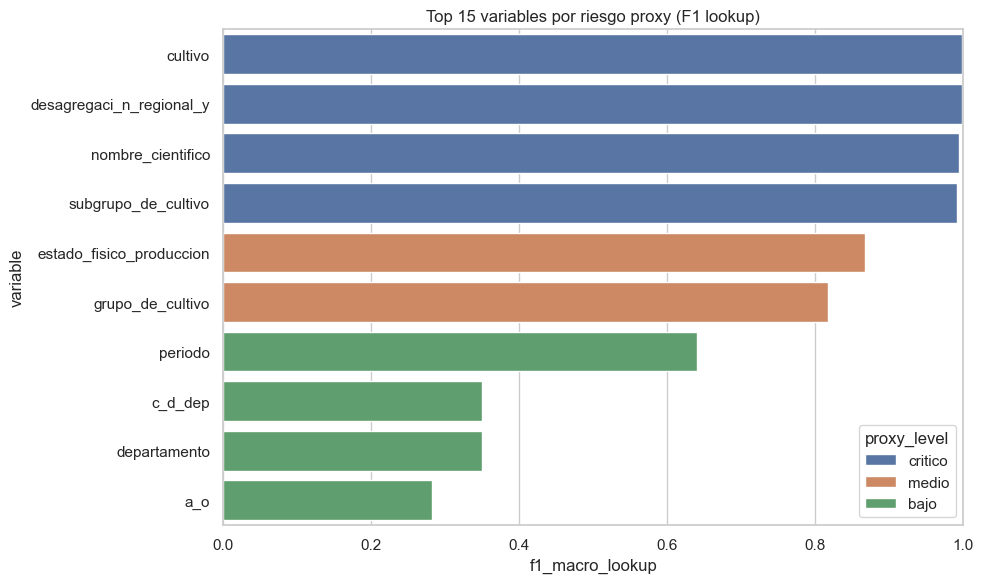

In [4]:
def one_col_lookup_score(df_in, col, target='ciclo_de_cultivo', test_size=0.2, random_state=42):
    work = df_in[[col, target]].dropna().copy()
    if work.empty:
        return np.nan, np.nan, 0
    train_df, test_df = train_test_split(work, test_size=test_size, stratify=work[target], random_state=random_state)
    mapping = train_df.groupby(col)[target].agg(lambda s: s.value_counts().index[0]).to_dict()
    fallback = train_df[target].mode().iloc[0]
    pred = test_df[col].map(mapping).fillna(fallback)
    return (
        accuracy_score(test_df[target], pred),
        f1_score(test_df[target], pred, average='macro', zero_division=0),
        len(test_df)
    )

feature_cols = [c for c in df.columns if c != TARGET_COLUMN]
rows = []
for c in feature_cols:
    s = df[c]
    if s.dtype == 'object' or s.dtype.name == 'string' or s.nunique(dropna=True) <= 300:
        acc, f1m, n = one_col_lookup_score(df, c, target=TARGET_COLUMN, random_state=RANDOM_STATE)
        rows.append({
            'variable': c,
            'dtype': str(s.dtype),
            'n_unique': int(s.nunique(dropna=True)),
            'n_test': int(n),
            'accuracy_lookup': float(acc),
            'f1_macro_lookup': float(f1m)
        })

proxy_screen_df = pd.DataFrame(rows).sort_values(['f1_macro_lookup', 'accuracy_lookup'], ascending=False)
proxy_screen_df['proxy_level'] = np.select(
    [
        proxy_screen_df['f1_macro_lookup'] >= 0.97,
        proxy_screen_df['f1_macro_lookup'] >= 0.90,
        proxy_screen_df['f1_macro_lookup'] >= 0.80
    ],
    ['critico','alto','medio'],
    default='bajo'
)

proxy_strong = proxy_screen_df.loc[proxy_screen_df['proxy_level'].isin(['critico', 'alto']), 'variable'].tolist()
proxy_medium = proxy_screen_df.loc[proxy_screen_df['proxy_level'] == 'medio', 'variable'].tolist()

proxy_screen_df.to_csv(OUT_DIR / 'proxy_screening_full.csv', index=False)

removal_rules = pd.DataFrame([
    {'regla': 'Critico/Alto por lookup', 'variables': ', '.join(proxy_strong), 'decision': 'Remover'},
    {'regla': 'Medio con justificacion semantica', 'variables': ', '.join(proxy_medium), 'decision': 'Evaluar/remover conservadoramente'}
])
removal_rules.to_csv(OUT_DIR / 'proxy_removal_rules.csv', index=False)

display(proxy_screen_df.head(20))
display(removal_rules)

plt.figure(figsize=(10,6))
plot_df = proxy_screen_df.head(15)
sns.barplot(data=plot_df, x='f1_macro_lookup', y='variable', hue='proxy_level', dodge=False)
plt.title('Top 15 variables por riesgo proxy (F1 lookup)')
plt.xlim(0,1)
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'proxy_ranking_top15.png', dpi=150)
plt.show()

## 5. Construccion del Dataset Sin Proxies

In [7]:
proxy_cols_final = [
    'cultivo',
    'subgrupo_de_cultivo',
    'nombre_cientifico',
    'estado_fisico_produccion',
    'desagregaci_n_regional_y'
]

X_full = df.drop(columns=[TARGET_COLUMN]).copy()
y_full = df[TARGET_COLUMN].copy()
drop_existing = [c for c in proxy_cols_final if c in X_full.columns]
X_clean = X_full.drop(columns=drop_existing).copy()

integrity = pd.DataFrame([
    {'item': 'filas_dataset', 'valor': int(df.shape[0])},
    {'item': 'columnas_originales', 'valor': int(X_full.shape[1])},
    {'item': 'columnas_removidas', 'valor': int(len(drop_existing))},
    {'item': 'columnas_finales', 'valor': int(X_clean.shape[1])}
])

integrity.to_csv(OUT_DIR / 'dataset_integrity_checks.csv', index=False)
pd.DataFrame({'removed_proxy_columns': drop_existing}).to_csv(OUT_DIR / 'removed_proxy_columns.csv', index=False)

df_clean = pd.concat([X_clean, y_full], axis=1)
snapshot_parquet = OUT_DIR / 'dataset_proxy_safe_snapshot.parquet'
snapshot_csv = OUT_DIR / 'dataset_proxy_safe_snapshot.csv.gz'

snapshot_msg = ''
try:
    df_clean.to_parquet(snapshot_parquet, index=False)
    snapshot_msg = f'Snapshot guardado en parquet: {snapshot_parquet}'
except Exception:
    # Fallback portable cuando no hay motor parquet disponible
    df_clean.to_csv(snapshot_csv, index=False, compression='gzip')
    snapshot_msg = f'Snapshot guardado en CSV comprimido: {snapshot_csv}'

display(integrity)
print(snapshot_msg)

,item,valor
0,filas_dataset,206068
1,columnas_originales,16
2,columnas_removidas,5
3,columnas_finales,11


Snapshot guardado en CSV comprimido: reports\notebook_evidencias_proxy_safe\dataset_proxy_safe_snapshot.csv.gz


## 6. Preprocesamiento Multiclase (Pipeline Reutilizable)

In [6]:
def group_rare_categories(df_input, cat_cols, top_n=30, rare_label='OTROS'):
    df_out = df_input.copy()
    for c in cat_cols:
        if c not in df_out.columns:
            continue
        vc = df_out[c].value_counts(dropna=True)
        top_values = set(vc.head(top_n).index)
        df_out[c] = df_out[c].where(df_out[c].isin(top_values), rare_label)
    return df_out

cat_cols = X_clean.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()
X_clean = group_rare_categories(X_clean, cat_cols, top_n=30, rare_label='OTROS')

X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, y_full, test_size=0.30, stratify=y_full, random_state=RANDOM_STATE
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

split_info = pd.DataFrame([
    {'split': 'train', 'rows': len(X_train)},
    {'split': 'valid', 'rows': len(X_valid)},
    {'split': 'test', 'rows': len(X_test)}
])
split_info.to_csv(OUT_DIR / 'split_info.csv', index=False)
display(split_info)

,split,rows
0,train,144247
1,valid,30910
2,test,30911


## 7. Reejecucion Completa de Iteraciones y Pruebas del Informe

In [15]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'),
    'RandomForest': RandomForestClassifier(n_estimators=320, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'SVM_RBF': SVC(kernel='rbf', C=3, gamma='scale', class_weight='balanced')
}

iter_rows = []
pred_store = {}

for name, model in models.items():
    steps = [('preprocessor', preprocessor)]
    if name in ['KNN', 'SVM_RBF']:
        steps.extend([('svd', TruncatedSVD(n_components=40, random_state=RANDOM_STATE)), ('scaler_dense', StandardScaler())])
    steps.append(('model', model))
    pipe = Pipeline(steps)

    pipe.fit(X_train, y_train)
    pred_v = pipe.predict(X_valid)
    pred_store[name] = pred_v

    iter_rows.append({
        'modelo': name,
        'split': 'valid',
        'accuracy': accuracy_score(y_valid, pred_v),
        'precision_macro': precision_score(y_valid, pred_v, average='macro', zero_division=0),
        'recall_macro': recall_score(y_valid, pred_v, average='macro', zero_division=0),
        'f1_macro': f1_score(y_valid, pred_v, average='macro', zero_division=0)
    })

iter_df = pd.DataFrame(iter_rows).sort_values('f1_macro', ascending=False)
iter_df.to_csv(OUT_DIR / 'iterations_validation_metrics.csv', index=False)
display(iter_df)

,modelo,split,accuracy,precision_macro,recall_macro,f1_macro
1,RandomForest,valid,0.980492,0.942505,0.951406,0.946842
2,KNN,valid,0.969136,0.908149,0.929443,0.918050
3,SVM_RBF,valid,0.958395,0.875927,0.959233,0.904454
0,LogisticRegression,valid,0.954675,0.868706,0.953471,0.896865


## 8. Modelado Multiclase Rehecho (Baseline y Modelos Candidatos)

In [14]:
# Seleccion de mejor modelo en validacion (con fallback seguro)
if 'iter_df' in globals() and not iter_df.empty:
    best_model_name = iter_df.iloc[0]['modelo']
elif 'test_df' in globals() and not test_df.empty:
    best_model_name = test_df.iloc[0]['modelo']
else:
    best_model_name = 'No disponible'

print('Best model candidate:', best_model_name)

Best model candidate: RandomForest


In [8]:
# Reentreno en train+valid y evalúo en test
X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'),
    'RandomForest': RandomForestClassifier(n_estimators=320, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'SVM_RBF': SVC(kernel='rbf', C=3, gamma='scale', class_weight='balanced')
}

test_rows = []
test_pred_store = {}
for name, model in base_models.items():
    steps = [('preprocessor', preprocessor)]
    if name in ['KNN', 'SVM_RBF']:
        steps.extend([('svd', TruncatedSVD(n_components=40, random_state=RANDOM_STATE)), ('scaler_dense', StandardScaler())])
    steps.append(('model', model))
    pipe = Pipeline(steps)

    pipe.fit(X_train_full, y_train_full)
    pred_t = pipe.predict(X_test)
    test_pred_store[name] = pred_t

    test_rows.append({
        'modelo': name,
        'accuracy': accuracy_score(y_test, pred_t),
        'precision_macro': precision_score(y_test, pred_t, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, pred_t, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, pred_t, average='macro', zero_division=0)
    })

test_df = pd.DataFrame(test_rows).sort_values('f1_macro', ascending=False)
test_df.to_csv(OUT_DIR / 'final_test_metrics_proxy_safe.csv', index=False)
display(test_df)

,modelo,accuracy,precision_macro,recall_macro,f1_macro
1,RandomForest,0.981851,0.948317,0.951505,0.949897
2,KNN,0.971402,0.916565,0.928004,0.922077
3,SVM_RBF,0.961794,0.882643,0.961410,0.910732
0,LogisticRegression,0.957426,0.873882,0.956261,0.902067


## 9. Evaluacion Integral y Validacion de Realismo de Resultados

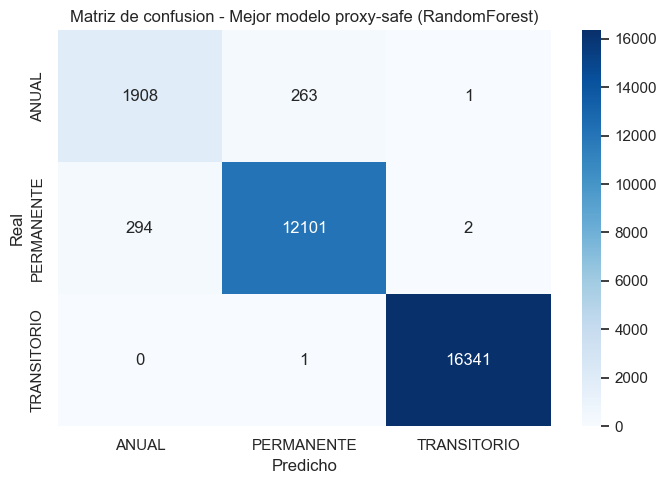

Mejor modelo: RandomForest
              precision    recall  f1-score   support

       ANUAL       0.87      0.88      0.87      2172
  PERMANENTE       0.98      0.98      0.98     12397
 TRANSITORIO       1.00      1.00      1.00     16342

    accuracy                           0.98     30911
   macro avg       0.95      0.95      0.95     30911
weighted avg       0.98      0.98      0.98     30911



In [10]:
best_name_test = test_df.iloc[0]['modelo']
best_pred_test = test_pred_store[best_name_test]

labels = sorted(y_test.dropna().unique().tolist())
cm = confusion_matrix(y_test, best_pred_test, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Matriz de confusion - Mejor modelo proxy-safe ({best_name_test})')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'best_model_confusion_matrix.png', dpi=150)
plt.show()

report_txt = classification_report(y_test, best_pred_test, zero_division=0)
with open(OUT_DIR / 'classification_report_best_model.txt', 'w', encoding='utf-8') as f:
    f.write(report_txt)

print('Mejor modelo:', best_name_test)
print(report_txt)

,modelo,f1_original_con_proxies,f1_proxy_safe,caida_f1
0,KNN,0.974997,0.780020,0.194977
1,SVM_RBF,0.998838,0.880991,0.117847
2,LogisticRegression,0.998843,0.881241,0.117602
3,RandomForest,0.997869,0.919730,0.078139


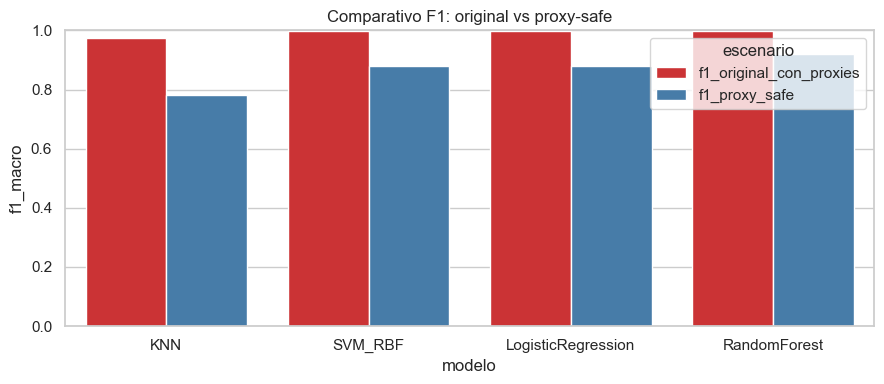

In [11]:
# Comparativo con resultados originales del informe principal (si existe archivo)
orig_path = ROOT / 'reports' / 'informe_modelado_proxy_safe' / 'model_f1_drop_proxy_safe_vs_original.csv'
if orig_path.exists():
    orig_cmp = pd.read_csv(orig_path)
    display(orig_cmp)

    plt.figure(figsize=(9,4))
    plot_cmp = orig_cmp.melt(id_vars=['modelo'], value_vars=['f1_original_con_proxies', 'f1_proxy_safe'], var_name='escenario', value_name='f1_macro')
    sns.barplot(data=plot_cmp, x='modelo', y='f1_macro', hue='escenario', palette='Set1')
    plt.title('Comparativo F1: original vs proxy-safe')
    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'f1_compare_original_vs_proxy_safe.png', dpi=150)
    plt.show()
else:
    print('No se encontro comparativo previo en', orig_path)

## 10. Organizacion de Resultados, Trazabilidad y Exportables del Informe

In [16]:
summary_lines = []
summary_lines.append('# Resumen Reproducible del Notebook de Evidencias')
summary_lines.append('')
summary_lines.append(f'- Filas analizadas: {df.shape[0]:,}')
summary_lines.append(f'- Columnas originales (sin target): {X_full.shape[1]}')
summary_lines.append(f'- Columnas removidas por proxy: {len(drop_existing)}')
summary_lines.append(f'- Mejor modelo final proxy-safe: {best_name_test}')
best_row = test_df.iloc[0]
summary_lines.append(
    f"- Metricas test del mejor modelo: accuracy={best_row['accuracy']:.6f}, f1_macro={best_row['f1_macro']:.6f}"
)
summary_lines.append('')
summary_lines.append('## Columnas removidas')
for c in drop_existing:
    summary_lines.append(f'- {c}')
summary_lines.append('')
summary_lines.append('## Archivos generados')
for p in sorted(OUT_DIR.glob('*')):
    if p.is_file():
        summary_lines.append(f'- {p.name}')
summary_lines.append('- assets/')

summary_text = '\n'.join(summary_lines)
with open(OUT_DIR / 'RESUMEN_NOTEBOOK_EVIDENCIAS.md', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(summary_text)
print('\nCarpeta final de evidencias:', OUT_DIR)

# Resumen Reproducible del Notebook de Evidencias

- Filas analizadas: 206,068
- Columnas originales (sin target): 16
- Columnas removidas por proxy: 5
- Mejor modelo final proxy-safe: RandomForest
- Metricas test del mejor modelo: accuracy=0.981851, f1_macro=0.949897

## Columnas removidas
- cultivo
- subgrupo_de_cultivo
- nombre_cientifico
- estado_fisico_produccion
- desagregaci_n_regional_y

## Archivos generados
- class_distribution.csv
- classification_report_best_model.txt
- dataset_integrity_checks.csv
- dataset_metadata.json
- dataset_proxy_safe_snapshot.csv.gz
- final_test_metrics_proxy_safe.csv
- iterations_validation_metrics.csv
- missing_profile.csv
- proxy_removal_rules.csv
- proxy_screening_full.csv
- removed_proxy_columns.csv
- RESUMEN_NOTEBOOK_EVIDENCIAS.md
- split_info.csv
- assets/

Carpeta final de evidencias: reports\notebook_evidencias_proxy_safe
